In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from statsmodels.tsa.arima.model import ARIMA

In [2]:
import os
os.getcwd()

'/Users/shardul/Inverse_problems_in_QM/notebooks/agnr/time_series'

In [5]:
pristine_9 = np.load("../../../9_agnr_pris.csv.npy")
pristine_7 = np.load("../../../7_agnr_pris.csv.npy")

In [6]:
X_7 = np.load(os.path.expanduser("~/transmission_data/consolidated_data/size_7.npy"))
X_9 = np.load(os.path.expanduser("~/transmission_data/consolidated_data/size_9.npy"))

In [7]:
concs = np.arange(2, 60, 2)
indices = concs // 2 - 1


X_7_train = np.clip(X_7[indices, :10000,:150],0,3).reshape(-1,150)
X_9_train = np.clip(X_9[indices, :10000,:150],0,4).reshape(-1,150)
Y_7_predict = np.clip(X_7[indices, :10000,150:170],0,3).reshape(-1,20)
Y_9_predict = np.clip(X_9[indices, :10000,150:170],0,4).reshape(-1,20)


In [9]:
X_train = np.vstack([X_7_train,X_9_train])
Y_train = np.vstack([Y_7_predict,Y_9_predict])

In [10]:
df_X = pd.DataFrame(X_train,columns=[f"signal_{i}" for i in range(150)])
df_Y = pd.DataFrame(Y_train,columns=[f"signal_{i}" for i in range(20)])

In [11]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

In [12]:
random_sample = df_X.sample(frac=0.8,random_state=42).index
test_sample = df_X.index.difference(random_sample)

In [13]:
train = df_X.loc[random_sample]
target = df_Y.loc[random_sample]
test_input = df_X.loc[test_sample]
target_input = df_Y.loc[test_sample]

In [14]:
import lightgbm as lgbm
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import root_mean_squared_error

In [15]:
import os
from functools import lru_cache
import copy
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

import scipy.sparse as sp
from scipy.sparse import csr_matrix, diags
from scipy.linalg import lu_factor, lu_solve, solve
#from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist, squareform

import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset


In [22]:
class mulit_prediction(nn.Module):
    def __init__(self, input_len = 150, final_hidden_dim = 20):
        super().__init__()


        self.model = nn.Sequential(
            nn.Linear(input_len,256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256,256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128,final_hidden_dim)
        )

    def forward(self,x: torch.tensor):
        return self.model(x)


In [23]:
Xtr = train.values.astype(np.float32)
Ytr = target.values.astype(np.float32)
Xte = test_input.values.astype(np.float32)
Yte = target_input.values.astype(np.float32)

train_ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(Ytr))
val_ds = TensorDataset(torch.from_numpy(Xte), torch.from_numpy(Yte))
dev = "mps" if torch.backends.mps.is_available() else "cpu"
Xte_t = torch.from_numpy(Xte).to(dev)

In [49]:
def own_loss(x, y):
    return torch.abs(x - y).sum(dim=1).mean()    # mean over spectra of ∫|ΔT| dE

In [50]:

def training_model(num_epochs, device = dev):
        
        model = mulit_prediction(input_len=150, final_hidden_dim=20).to(device)

        optimizer = optim.Adam(model.parameters(), lr=0.001)
    
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=3
        )

        train_dl = DataLoader(train_ds, batch_size=1024, shuffle=True, drop_last=True)
        val_dl = DataLoader(val_ds,batch_size=512, shuffle=False)


        train_loss_his = []
        val_loss_his = []


        best_val_loss = float('inf')
        best_model_weights = None

        for epoch in range(num_epochs):
                model.train()
                running_loss = 0


                for xb, yb in train_dl:
                        xb = xb.to(device)
                        yb = yb.to(device)


                        preds = model(xb)


                        loss = own_loss(preds,yb)

                        optimizer.zero_grad()

                        loss.backward()
                        optimizer.step()

                        running_loss += loss.item()

                avg_train = running_loss / len(train_dl)
                train_loss_his.append(avg_train)

        # -----------------------
        #     VALIDATION
        # -----------------------
        model.eval()
        running_val = 0.0

        with torch.no_grad():
            for xb, yb in val_dl:
                xb = xb.to(device)
                yb = yb.to(device)

                preds = model(xb)
                          
                loss = loss = own_loss(preds,yb) 

                running_val += loss.item()

        avg_val = running_val / len(val_dl)
        val_loss_his.append(avg_val)
        
        # -----------------------
        # UPDATES & CHECKPOINTING
        # -----------------------
        scheduler.step(avg_val)

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_model_weights = copy.deepcopy(model.state_dict())
            print(f"Epoch {epoch+1:03d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} * Saved Best")
        else:
            print(f"Epoch {epoch+1:03d} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")
    
    
        if best_model_weights is not None:
                model.load_state_dict(best_model_weights)
                print(f"\nTraining Complete. Loaded best model with Val Loss: {best_val_loss:.4f}")

        # PLOT LOSSES
        plt.figure(figsize=(10,6))
        plt.plot(train_loss_his, label="Train Loss")
        plt.plot(val_loss_his, label="Validation Loss")
        best_epoch_idx = val_loss_his.index(best_val_loss)
        plt.axvline(best_epoch_idx, color='green', linestyle='--', label='Best Model')
        
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training & Validation Loss")
        plt.legend()
        plt.grid(True)
        plt.show()
        
        return model, (train_loss_his, val_loss_his)

In [51]:
trained_model = training_model(150)

KeyboardInterrupt: 

In [41]:
a,b = trained_model

In [42]:
a

mulit_prediction(
  (model): Sequential(
    (0): Linear(in_features=150, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=20, bias=True)
  )
)

In [29]:
F.mse_loss(torch.from_numpy(Ytr[0]),torch.from_numpy(Ytr[1]))

tensor(2.0818)

In [44]:
a.eval()
with torch.no_grad():
    preds = torch.cat([a(Xte_t[i:i+8192]).cpu()
                       for i in range(0, len(Xte_t), 8192)]).numpy()

mdl  = np.abs(preds - Yte)              # model error
pers = np.abs(Xte[:, -1:] - Yte)        # persistence baseline

print(f"model MAE       {mdl.mean():.4f}")
print(f"persistence MAE {pers.mean():.4f}")


model MAE       0.3554
persistence MAE 0.5912


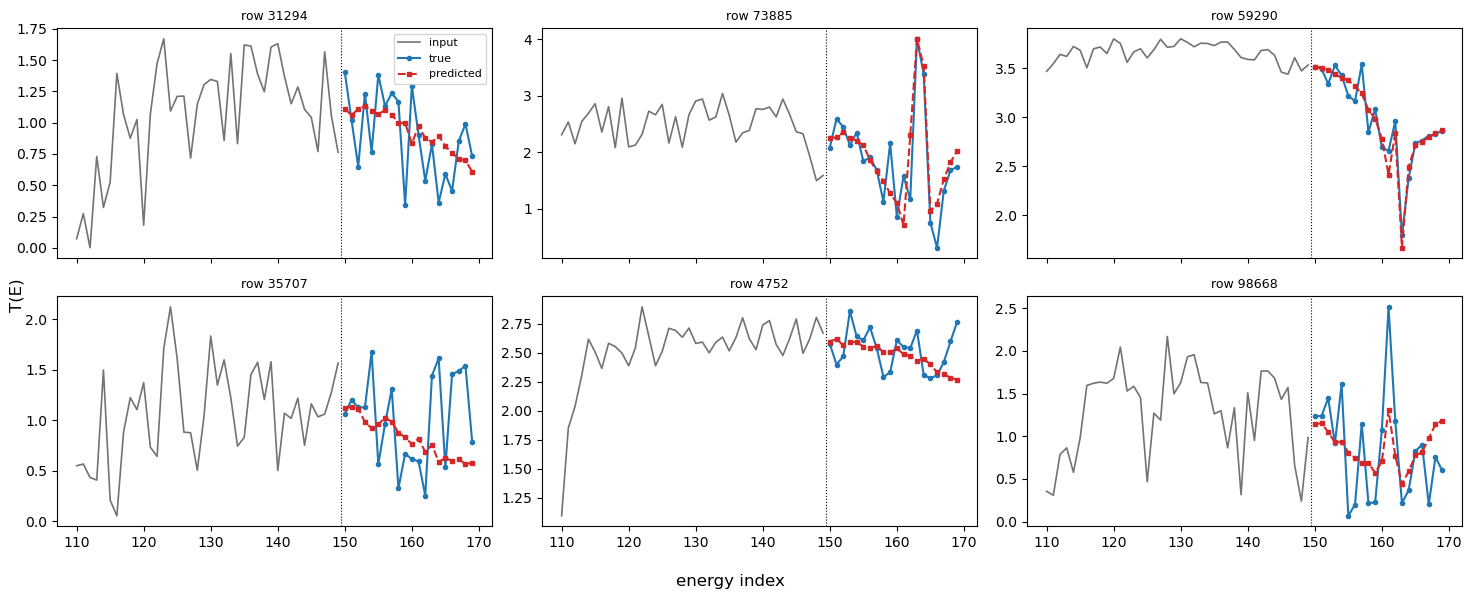

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
rows = np.random.default_rng(0).choice(len(Yte), 6, replace=False)

for ax, r in zip(axes.ravel(), rows):
    ax.plot(range(110, 150), Xte[r, 110:],  color="0.45", lw=1.2, label="input")
    ax.plot(range(150, 170), Yte[r],   "o-",  ms=3, color="C0", label="true")
    ax.plot(range(150, 170), preds[r], "s--", ms=3, color="C3", label="predicted")
    ax.axvline(149.5, color="k", ls=":", lw=0.8)
    ax.set_title(f"row {r}", fontsize=9)

axes[0, 0].legend(fontsize=8)
fig.supxlabel("energy index"); fig.supylabel("T(E)")
fig.tight_layout()